100%|██████████| 3562/3562 [03:14<00:00, 18.29it/s]


Всего документов: 35617902
Документов без тегов: 0 (0.0%)
Уникальных тегов: 788
Топ-20 тегов:
  #онлайн_магазины                          1735745
  #туризм                                   1692172
  #строительная_отрасль                     1515712
  #дизайн_интерьера                         1481130
  #образование_россии                       1479434
  #здоровье                                 1286910
  #производство                             1269790
  #акции_и_скидки                           1134688
  #игры                                     1125607
  #азартные_игры                            1069463
  #строительство                            1058397
  #услуги                                   1042953
  #медицина                                 1042592
  #эротика                                   964745
  #город_россии                              958858
  #отель                                     918046
  #финансы                                   894375
  #техника_и_технологи

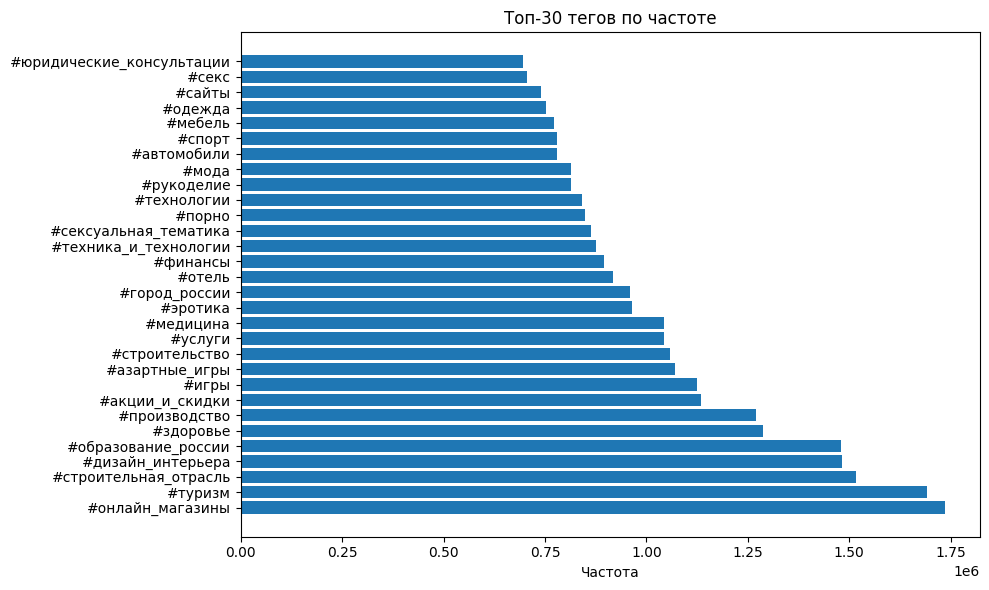

In [4]:
# сбор статистики по тегам

import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm


TAGS_DIR = Path("fineweb_tags")  
tag_counter = Counter()
total_docs = 0
empty_docs = 0

for jsonl_file in tqdm(sorted(TAGS_DIR.glob("*_tags.jsonl"))):
    with jsonl_file.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            total_docs += 1
            tags_str = record.get("tags", "")
            if not tags_str:
                empty_docs += 1
                continue
            tags = tags_str.split()
            tag_counter.update(tags)


print(f"Всего документов: {total_docs}")
print(f"Документов без тегов: {empty_docs} ({(empty_docs/total_docs)*100:.1f}%)")
print(f"Уникальных тегов: {len(tag_counter)}")
print(f"Топ-20 тегов:")
for tag, count in tag_counter.most_common(20):
    print(f"  {tag:40s} {count:>8d}")

top_tags = tag_counter.most_common(30)
tags, counts = zip(*top_tags)

plt.figure(figsize=(10, 6))
plt.barh(range(len(tags)), counts, tick_label=tags)
plt.xlabel("Частота")
plt.title("Топ-30 тегов по частоте")
plt.tight_layout()
plt.savefig("top_tags.png", dpi=150)
plt.show()

In [14]:
# поиск тегов, связанных с юридическим доменом

import json
import torch
from sentence_transformers import SentenceTransformer

with open('bert_tagging/model/multilabel_llm_no_abbriv_tags/checkpoint-18500/config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)
tags = list(config['id2label'].values())
tags = [' '.join(tag[1:].split('_')) for tag in tags]

query = "законы, право, судебная практика"

tag_sentences = [f"Тексты про {tag}" for tag in tags]
query_sentence = f"Тексты про {query}"

model = SentenceTransformer('sergeyzh/BERTA')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

tag_embeddings = model.encode(tag_sentences, prompt="paraphrase: ", convert_to_tensor=True).to(device)
query_embedding = model.encode(query_sentence, prompt="paraphrase: ", convert_to_tensor=True).to(device)

tag_embeddings_norm = torch.nn.functional.normalize(tag_embeddings, p=2, dim=1)
query_embedding_norm = torch.nn.functional.normalize(query_embedding, p=2, dim=0)

cosine_scores = torch.matmul(tag_embeddings_norm, query_embedding_norm)

scores_np = cosine_scores.cpu().numpy()

pairs = [(tags[i], scores_np[i]) for i in range(len(tags))]
pairs.sort(key=lambda x: x[1], reverse=True)

selected_tags = [(tag, score) for tag, score in pairs]

print(f"Теги, релевантные запросу '{query}':")
for tag, score in selected_tags:
    print(f"{tag:30s} | сходство: {score:.4f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8257.73it/s]


Теги, релевантные запросу 'законы, право, судебная практика':
законодательство               | сходство: 0.8933
право                          | сходство: 0.8852
суды                           | сходство: 0.8547
юридические консультации       | сходство: 0.8240
судебные иски и претензии      | сходство: 0.7542
трудовые права                 | сходство: 0.7392
банковское дело                | сходство: 0.7293
медицина                       | сходство: 0.7170
уголовное наказание            | сходство: 0.7097
правоохранительные органы      | сходство: 0.7055
договоры                       | сходство: 0.7047
журналистика                   | сходство: 0.7027
государственная деятельность   | сходство: 0.7014
государственное управление     | сходство: 0.6965
государственные системы        | сходство: 0.6925
охрана и безопасность          | сходство: 0.6918
работа с документами           | сходство: 0.6880
здравоохранение                | сходство: 0.6867
налогообложение                | сходс

In [28]:
import json
from pathlib import Path
from tqdm import tqdm

metadata = Path('fineweb_tags')
tag_filter = Path('tag_map_legal_reasoning.json')
output = Path('legal_domain.jsonl')

with tag_filter.open('r', encoding='utf-8') as f:
    tag_filter = json.load(f)
active_tags = {tag for tag, flag in tag_filter.items() if flag}

selected = []
tag_dict: dict[int, int] = dict(zip(range(1, 6), [0]*5))
for tags_file in tqdm(metadata.glob("*_tags.jsonl")):
    with open(tags_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            record = json.loads(line)
            file_name = record["file"]
            idx = record["line_idx"]
            tags_str = record["tags"]
            tags_list = tags_str.split()

            if (true_tags_count := len(set(active_tags) & set(tags_list))) >= 2:
                selected.append({"file_name": file_name, "idx": idx, 'confidence': true_tags_count})
                tag_dict[true_tags_count] += 1

with output.open('w', encoding='utf-8') as f:
    for entry in selected:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"Готово. Найдено записей: {len(selected)}")
print(f'Confidence: {tag_dict}')


3562it [03:19, 17.81it/s]


Готово. Найдено записей: 2823518
Confidence: {1: 0, 2: 1551038, 3: 732437, 4: 358992, 5: 181051}


In [23]:
# проверка файлов на наличие в них тегов из юридического домена

import json

file_name = 'part-01128'
idx = int(7551)

base_dir = "mini_fineweb2_rus_all_data"
file_path = f"{base_dir}/{file_name}"

with open(f'{file_path}.jsonl', "r", encoding="utf-8") as f:
    lines = f.readlines()

with open(f'fineweb_tags/{file_name}_tags.jsonl') as f:
    tags = f.readlines()

if idx < 0 or idx >= len(lines):
    print(f"Ошибка: индекс {idx} вне диапазона (всего строк: {len(lines)})")

record = json.loads(lines[idx])
tags = json.loads(tags[idx])
print(record["text"])
print(tags['tags'])

with open('tag_map_legal_reasoning.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

for i in tags['tags'].split():
    if i in data:
        print(f'{i} - {data[i]}')

Трагедия произошла сегодня, 19 октября, около пяти утра в Ростове. Там загорелся восьмиквартирный дом на улице Ленинской. Площадь пожара составила 600 квадратных метров.
В региональном управлении Следственного комитета подтвердили гибель шестерых человек, уточнив, что по предварительной информации, пятеро из них дети.
По факту произошедшего возбудили уголовное дело по статье «причинение смерти по неосторожности двум или более лицам».
По информации департамента здравоохранения Ярославской области, три человека госпитализированы в Ростовскую районную больницу. Двое в реанимации, один в отделении травматологии.
#расследование #происшествия #трагедия #преступность #катастрофы
#расследование - True
#происшествия - False
#трагедия - False
#преступность - True
#катастрофы - False
